In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

plt.rcParams['font.family']='Malgun Gothic'


In [160]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("willianoliveiragibin/healthcare-insurance")



In [161]:
insurance_data = pd.read_csv('content/insurance.csv')

insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [162]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [163]:
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [164]:
insurance_data.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

<Axes: xlabel='age'>

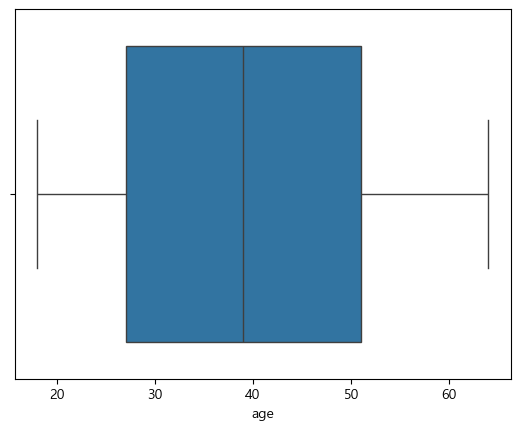

In [165]:
#sns.boxplot(x=insurance_data['charges'])
sns.boxplot(x=insurance_data['age'])
#sns.boxplot(x=insurance_data['smoker'])
#sns.boxplot(x=insurance_data['charges'])

# ---  ------    --------------  -----  
#  0   age       1338 non-null   int64  
#  1   sex       1338 non-null   object 
#  2   bmi       1338 non-null   float64
#  3   children  1338 non-null   int64  
#  4   smoker    1338 non-null   object 
#  5   region    1338 non-null   object 
#  6   charges   1338 non-null   float64

In [166]:
df = insurance_data[['age','sex','bmi','children','smoker','charges']]

In [167]:
print(df['sex'].unique())
print(df['children'].unique())
print(df['age'].unique())

['female' 'male']
[0 1 3 2 5 4]
[19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]


In [168]:
df['age_range'] = df['age']//10*10
df

,age,sex,bmi,children,smoker,charges,age_range
0,19,female,27.900,0,yes,16884.92400,10
1,18,male,33.770,1,no,1725.55230,10
2,28,male,33.000,3,no,4449.46200,20
3,33,male,22.705,0,no,21984.47061,30
4,32,male,28.880,0,no,3866.85520,30
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830,50
1334,18,female,31.920,0,no,2205.98080,10
1335,18,female,36.850,0,no,1629.83350,10
1336,21,female,25.800,0,no,2007.94500,20


Text(0.5, 1.0, 'Correlation Heatmap')

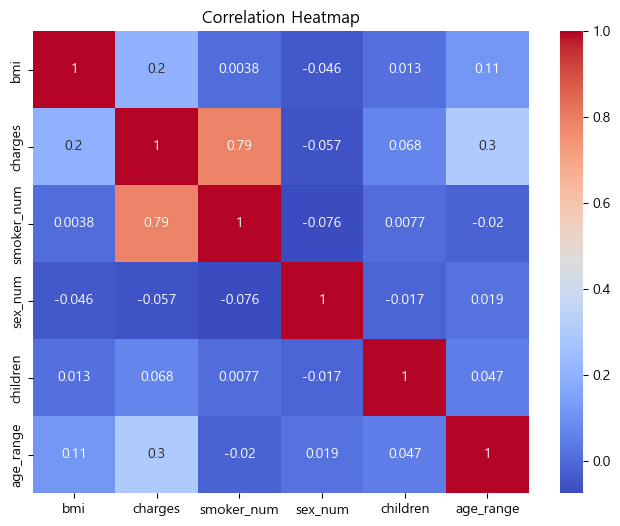

In [169]:
df_charge = df[['bmi','charges','smoker','age_range','sex','children']]
df_charge['smoker_num'] = df_charge['smoker'].map({'yes': 1, 'no': 0})
df_charge['sex_num'] = df_charge['sex'].map({'male':0,'female':1})
df_charge = df_charge[['bmi','charges','smoker_num','sex_num','children','age_range']]

plt.figure(figsize=(8, 6))

sns.heatmap(df_charge.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')


Text(0.5, 1.0, '연령대별 보험료 납부')

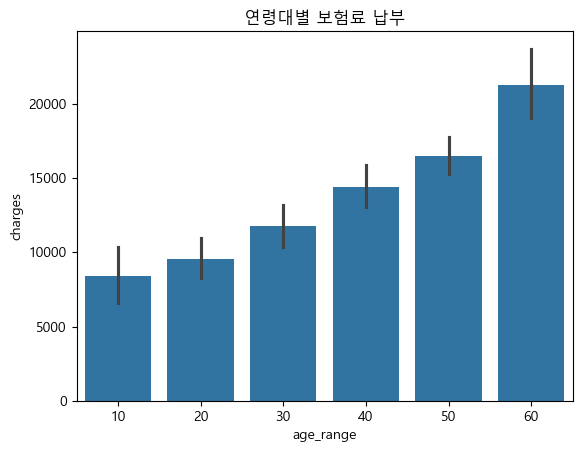

In [170]:
sns.barplot(data=df, x='age_range',y='charges')
plt.title("연령대별 보험료 납부")

Text(0.5, 1.0, '연령대별-성별 BMI 지수')

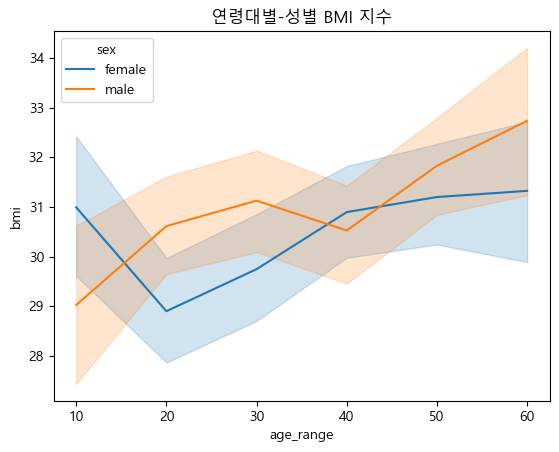

In [171]:
sns.lineplot(data=df,x='age_range',y='bmi',hue='sex')
plt.title("연령대별-성별 BMI 지수")

Text(0.5, 1.0, '연령대별-성별 흡연')

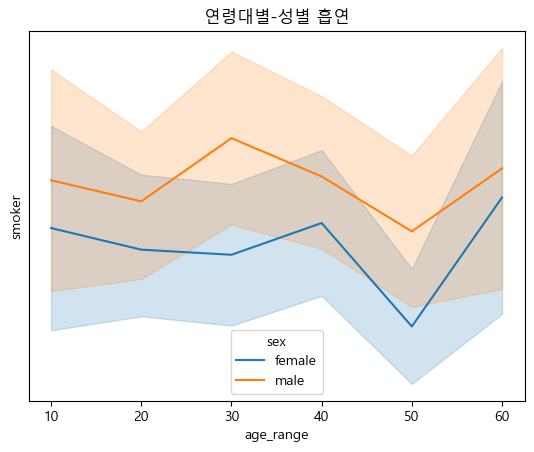

In [172]:
sns.lineplot(data=df, x='age_range',y='smoker',hue='sex')
plt.title("연령대별-성별 흡연")

Text(0.5, 1.0, '연령대별-흡연여부별 보험료')

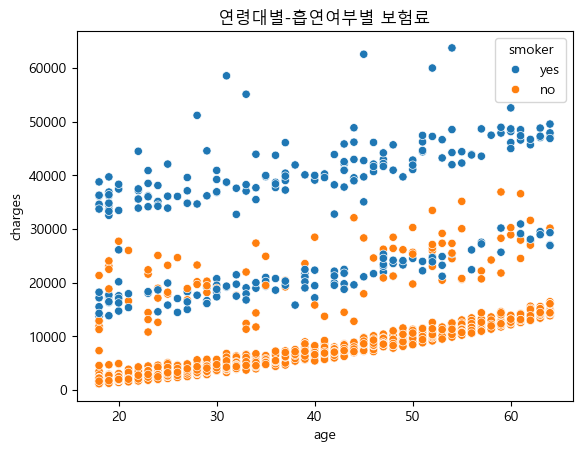

In [173]:
sns.scatterplot(data=df, x='age',y='charges',hue='smoker')
plt.title("연령대별-흡연여부별 보험료")

Text(0.5, 1.0, '흡연 여부에 따른 보험료')

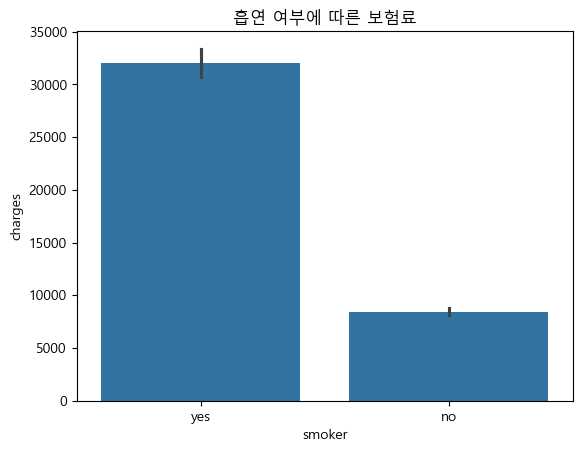

In [174]:
sns.barplot(data=df, x='smoker',y='charges')

plt.title("흡연 여부에 따른 보험료")

In [175]:
# 건강이 상당히 여러가지의 항목의 영향을 받기 때문에, 특정 한두가지의 항목과 비교하여 건강에 영향을 주는것을 확인하기 쉽지않지만 그럼에도 불구하고 흡연은 유의미하게 보험료를 올리는 요소이다.
# 흡연이 건강에 미치는 영향력의 크기를 알 수 있었다
